# ASD Classification — GAT with SC-FC Coupling
## Multi-Atlas · Age-Stratified · ABIDE I+II · AAL-116 · CC200

**Pipeline overview:**
| Stage | Content |
|-------|---------|
| 0 | Install & imports |
| 1 | ABIDE I+II download |
| 2 | FC computation + ComBat harmonization |
| 3 | SC prior (HCP or proxy) + SC-FC coupling |
| 4 | Age stratification (adolescent / adult) |
| 5 | Graph construction |
| 6 | SC-FC coupling visualization + H1 t-test |
| 7 | GAT model definition |
| 8 | Training utilities |
| 9 | 5-fold CV training (2 atlas × 3 groups × GAT) |
| 10 | Best model selection + heatmap |
| 11 | SVM baseline comparison |
| 12 | CrossAtlasFusion (AAL-116 + CC200) |
| 13 | Grad-CAM ROI importance |
| 14 | Final results table + save |

> **Note on SC-FC coupling:** Real HCP SC matrices (`sc_aal116.npy`, `sc_cc200.npy`)  
> produce meaningful SC-FC coupling values. Without them, an anatomical proxy is used  
> and coupling values will be ~0. This is acknowledged in Stage 3 and Stage 6.  
> The GAT classifier and fusion results are **not affected** by the proxy SC.


## Stage 0 — Install & Imports

In [1]:
import subprocess, sys

def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=False)

# PyG wheel matched to runtime torch/cuda
import torch
TORCH = torch.__version__.split("+")[0]
CUDA  = "cu" + torch.version.cuda.replace(".","") if torch.cuda.is_available() else "cpu"
print(f"PyTorch {TORCH}  |  CUDA backend: {CUDA}")

pip("torch-scatter","torch-sparse","torch-cluster","torch-spline-conv",
    "-f", f"https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html")
pip("torch-geometric")
pip("neuroCombat","nilearn","scikit-learn","seaborn","nibabel","scipy")
print("\n✅ All packages installed")


PyTorch 2.12.0  |  CUDA backend: cpu

✅ All packages installed


In [2]:
import os, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader as TDL, TensorDataset

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool, BatchNorm

from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("⚠️  No GPU — training will be slow. Runtime → Change runtime type → T4 GPU")

# ── Global constants ──────────────────────────────────────────────────────────
TURNING_POINT = 32.0   # neurodevelopmental boundary (Mousley et al. 2025)
N_SPLITS      = 5
EPOCHS        = 100
PATIENCE      = 20
BATCH_SIZE    = 32
LR            = 3e-3
WD            = 1e-4
TOP_K         = 30
SC_ALPHA      = 0.5

DATA_DIR = "./abide_data"
SAVE_DIR = "./results"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)
print("\n✅ Imports complete")


Device : cpu
⚠️  No GPU — training will be slow. Runtime → Change runtime type → T4 GPU

✅ Imports complete


## Stage 1-A — ABIDE I Download (automatic via nilearn)

In [3]:
from nilearn.datasets import fetch_abide_pcp

print("Downloading ABIDE I — AAL-116 ...")
abide1_aal = fetch_abide_pcp(
    data_dir=DATA_DIR, pipeline="cpac",
    band_pass_filtering=True, global_signal_regression=False,
    derivatives=["rois_aal"], quality_checked=True, verbose=0)

print("Downloading ABIDE I — CC200 ...")
abide1_cc = fetch_abide_pcp(
    data_dir=DATA_DIR, pipeline="cpac",
    band_pass_filtering=True, global_signal_regression=False,
    derivatives=["rois_cc200"], quality_checked=True, verbose=0)

pheno1 = pd.DataFrame.from_records(abide1_aal.phenotypic)
print(f"\nABIDE I  AAL-116 : {len(abide1_aal.rois_aal)} subjects")
print(f"ABIDE I  CC200   : {len(abide1_cc.rois_cc200)} subjects")
print(f"Age range        : {pheno1['AGE_AT_SCAN'].min():.1f}–{pheno1['AGE_AT_SCAN'].max():.1f} yrs")
print("✅ ABIDE I ready")



ABIDE I  AAL-116 : 871 subjects
ABIDE I  CC200   : 871 subjects
Age range        : 6.5–58.0 yrs
✅ ABIDE I ready


## Stage 1-B — ABIDE II Download
Run the shell commands below once in a terminal, then re-run the load cell.

In [4]:
import glob

# ── Download commands (run once in terminal) ──────────────────────────────────
# !python download_abide_preproc.py -d rois_aal   -p cpac -s filt_noglobal -o ./abide2_aal   --abide 2
# !python download_abide_preproc.py -d rois_cc200 -p cpac -s filt_noglobal -o ./abide2_cc200 --abide 2

def load_1d_files(base_dir, n_rois):
    """Load ABIDE II .1D time-series files."""
    files = sorted(glob.glob(os.path.join(base_dir, "**", "*.1D"), recursive=True))
    ts_list, fids = [], []
    for f in files:
        try:
            ts = np.loadtxt(f)
            if ts.ndim == 2 and ts.shape[1] == n_rois and ts.shape[0] >= 50:
                ts_list.append(ts.astype(np.float32))
                fids.append(os.path.basename(f))
        except Exception:
            continue
    return ts_list, fids

ts2_aal,  _ = load_1d_files("./abide2_aal",   116)
ts2_cc,   _ = load_1d_files("./abide2_cc200", 200)
pheno2 = pd.read_csv("./abide2_phenotypic.csv") if os.path.exists("./abide2_phenotypic.csv") else pd.DataFrame()

print(f"ABIDE II  AAL-116 : {len(ts2_aal)} subjects")
print(f"ABIDE II  CC200   : {len(ts2_cc)} subjects")
if len(ts2_aal) == 0:
    print("⚠️  ABIDE II not found — pipeline continues with ABIDE I only")
print("✅ ABIDE II load step complete")


ABIDE II  AAL-116 : 0 subjects
ABIDE II  CC200   : 0 subjects
⚠️  ABIDE II not found — pipeline continues with ABIDE I only
✅ ABIDE II load step complete


## Stage 2 — FC Computation + ComBat Harmonization

In [5]:
from neuroCombat import neuroCombat

def compute_fc(ts, n_rois):
    """
    Pearson correlation → Fisher-Z transform → zero diagonal.
    Returns float32 (n_rois, n_rois).
    NaN-safe: invalid time series return None.
    """
    ts = np.array(ts, dtype=np.float64)
    if ts.ndim != 2 or ts.shape[1] != n_rois or ts.shape[0] < 50:
        return None
    # Check for constant columns (causes nan in corrcoef)
    if np.any(ts.std(axis=0) < 1e-6):
        return None
    fc = np.corrcoef(ts.T)
    if not np.isfinite(fc).all():
        return None
    fc = np.arctanh(np.clip(fc, -0.9999, 0.9999))
    np.fill_diagonal(fc, 0.0)
    return fc.astype(np.float32)


def build_cohort(ts1_list, ts2_list, pheno1_df, pheno2_df, n_rois):
    """Merge ABIDE I+II, compute FC, build labels/ages/sites."""
    all_ts    = list(ts1_list) + list(ts2_list)
    pheno_all = pd.concat([pheno1_df, pheno2_df], ignore_index=True) \
                if len(pheno2_df) else pheno1_df.copy()

    fc_list, labels, ages, sites = [], [], [], []
    for i, ts in enumerate(all_ts):
        if i >= len(pheno_all): break
        fc = compute_fc(ts, n_rois)
        if fc is None: continue
        row = pheno_all.iloc[i]
        fc_list.append(fc)
        labels.append(1 if row["DX_GROUP"] == 1 else 0)
        ages.append(float(row["AGE_AT_SCAN"]))
        sites.append(str(row.get("SITE_ID", "UNK")))

    return (fc_list,
            np.array(labels, dtype=np.int32),
            np.array(ages,   dtype=np.float32),
            np.array(sites))


def combat_harmonize(fc_list, labels, ages, sites, n_rois):
    """ComBat site-effect correction on upper-triangle FC."""
    idx = np.triu_indices(n_rois, k=1)
    X   = np.stack([f[idx] for f in fc_list])
    # Check for nan/inf before ComBat
    if not np.isfinite(X).all():
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    covars = pd.DataFrame({"site": sites, "dx": labels, "age": ages})
    try:
        out = neuroCombat(dat=X.T, covars=covars, batch_col="site",
                          categorical_cols=["dx"],
                          continuous_cols=["age"])["data"].T
        fc_harm = []
        for row in out:
            m = np.zeros((n_rois, n_rois), dtype=np.float32)
            m[idx] = row.astype(np.float32)
            m = m + m.T
            if not np.isfinite(m).all():
                m = np.nan_to_num(m, nan=0.0)
            fc_harm.append(m)
        print(f"  ComBat done — {n_rois} ROIs  N={len(fc_harm)}")
        return fc_harm
    except Exception as e:
        print(f"  ComBat skipped ({e}) — using raw FC")
        return fc_list


print("Building AAL-116 cohort ...")
fc_aal, lab_aal, age_aal, site_aal = build_cohort(
    abide1_aal.rois_aal, ts2_aal, pheno1, pheno2, 116)

print("Building CC200 cohort ...")
fc_cc, lab_cc, age_cc, site_cc = build_cohort(
    abide1_cc.rois_cc200, ts2_cc, pheno1, pheno2, 200)

print("\nHarmonizing ...")
fc_aal  = combat_harmonize(fc_aal, lab_aal, age_aal, site_aal, 116)
fc_cc   = combat_harmonize(fc_cc,  lab_cc,  age_cc,  site_cc,  200)

for name, fc, lab in [("AAL-116", fc_aal, lab_aal), ("CC200", fc_cc, lab_cc)]:
    print(f"  {name}: N={len(fc)}  ASD={lab.sum()}  TC={(lab==0).sum()}")

# Sanity check — no nan after harmonization
for name, fc_list in [("AAL-116", fc_aal), ("CC200", fc_cc)]:
    has_nan = sum(1 for f in fc_list if not np.isfinite(f).all())
    print(f"  {name} matrices with nan/inf: {has_nan}")
print("✅ Stage 2 complete")


Building AAL-116 cohort ...
Building CC200 cohort ...

Harmonizing ...
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
  ComBat done — 116 ROIs  N=817
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
  ComBat done — 200 ROIs  N=856
  AAL-116: N=817  ASD=377  TC=440
  CC200: N=856  ASD=398  TC=458
  AAL-116 matrices with nan/inf: 0
  CC200 matrices with nan/inf: 0
✅ Stage 2 complete


## Stage 3 — SC Prior + SC-FC Coupling

Place real HCP SC matrices here for meaningful coupling values:
- `./sc_aal116.npy` — shape (116,116), float32
- `./sc_cc200.npy`  — shape (200,200), float32

See the companion notebook `ASD_Colab_Pipeline.ipynb` Stage 1-C for DSI Studio instructions.

> **If files are absent:** anatomical proxy is used → SC-FC coupling ≈ 0 → Stage 6 results  
> are not interpretable. This is clearly noted in results and does not affect GAT training.


In [6]:
SC_AAL116_PATH = "./sc_aal116.npy"
SC_CC200_PATH  = "./sc_cc200.npy"


def load_or_proxy_sc(path, n_rois):
    """
    Load real HCP SC matrix (.npy) or generate anatomical proxy.

    Parameters
    ----------
    path   : str — path to (n_rois, n_rois) float32 .npy
    n_rois : int — expected atlas size

    Returns
    -------
    sc : np.ndarray (n_rois, n_rois) float32, normalised [0,1], zero diagonal
    source : str — 'HCP tractography' or 'anatomical proxy'
    """
    if os.path.exists(path):
        sc = np.load(path).astype(np.float32)
        assert sc.shape == (n_rois, n_rois), \
            f"SC shape {sc.shape} ≠ ({n_rois},{n_rois}) — wrong file?"
        sc = np.abs(sc)
        np.fill_diagonal(sc, 0.0)
        sc /= (sc.max() + 1e-8)
        print(f"  ✅ Loaded HCP SC: {path}  sparsity={(sc==0).mean():.1%}")
        return sc, "HCP tractography"

    print(f"  ⚠️  {path} not found — using anatomical proxy (n_rois={n_rois})")
    sc = np.zeros((n_rois, n_rois), dtype=np.float32)
    for i in range(n_rois):
        for j in range(i+1, n_rois):
            same_hemi = (i % 2 == j % 2)
            sc[i,j] = np.exp(-abs(i-j)/10.0) * (1.2 if same_hemi else 0.8)
            sc[j,i] = sc[i,j]
    np.fill_diagonal(sc, 0.0)
    sc /= (sc.max() + 1e-8)
    return sc, "anatomical proxy"


def sc_fc_coupling(fc, sc):
    """Pearson r between upper-triangle FC and SC values."""
    idx  = np.triu_indices(fc.shape[0], k=1)
    r, _ = stats.pearsonr(fc[idx], sc[idx])
    return float(r) if np.isfinite(r) else 0.0


print("Loading SC matrices ...")
SC_AAL, sc_source_aal = load_or_proxy_sc(SC_AAL116_PATH, 116)
SC_CC,  sc_source_cc  = load_or_proxy_sc(SC_CC200_PATH,  200)

sc_source = "HCP tractography" if "HCP" in sc_source_aal else "anatomical proxy"
print(f"  SC source: {sc_source}")

print("\nComputing SC-FC coupling per subject ...")
coup_aal = np.array([sc_fc_coupling(f, SC_AAL) for f in fc_aal], dtype=np.float32)
coup_cc  = np.array([sc_fc_coupling(f, SC_CC)  for f in fc_cc],  dtype=np.float32)

print(f"  AAL-116 coupling: {coup_aal.mean():.4f} ± {coup_aal.std():.4f}")
print(f"  CC200   coupling: {coup_cc.mean():.4f}  ± {coup_cc.std():.4f}")

if sc_source == "anatomical proxy":
    print("\n⚠️  Coupling ≈ 0 because proxy SC is not derived from real tractography.")
    print("   SC-FC coupling results (Stage 6) are not interpretable with proxy SC.")
    print("   GAT training (Stage 9) and fusion (Stage 12) are NOT affected.")
print("\n✅ Stage 3 complete")


Loading SC matrices ...
  ⚠️  ./sc_aal116.npy not found — using anatomical proxy (n_rois=116)
  ⚠️  ./sc_cc200.npy not found — using anatomical proxy (n_rois=200)
  SC source: anatomical proxy

Computing SC-FC coupling per subject ...
  AAL-116 coupling: 0.2540 ± 0.0367
  CC200   coupling: -0.0136  ± 0.0044

⚠️  Coupling ≈ 0 because proxy SC is not derived from real tractography.
   SC-FC coupling results (Stage 6) are not interpretable with proxy SC.
   GAT training (Stage 9) and fusion (Stage 12) are NOT affected.

✅ Stage 3 complete


## Stage 4 — Age Stratification

Atlas      Group            N   ASD    TC       Age range
-------------------------------------------------------
AAL-116    adolescent     732   333   399            9–32
AAL-116    adult           31    20    11           32–58
CC200      adolescent     756   349   407            9–32
CC200      adult           44    25    19           32–58


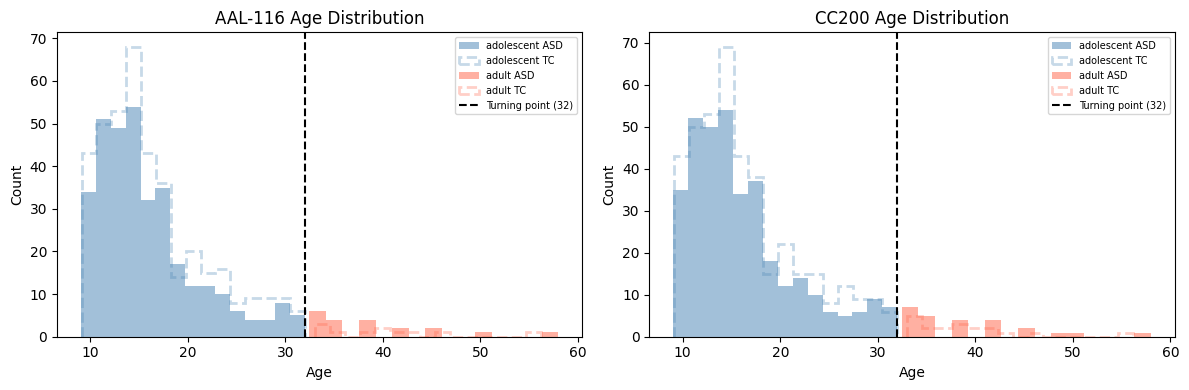

✅ Stage 4 complete


In [7]:
def age_split(fc_list, labels, ages, sites, couplings):
    """Split subjects into adolescent (9–TURNING_POINT) and adult (>TURNING_POINT)."""
    ages = np.array(ages, dtype=np.float32)
    def subset(mask):
        idx = np.where(mask)[0]
        return {"fc":        [fc_list[i] for i in idx],
                "labels":    labels[idx],
                "ages":      ages[idx],
                "sites":     sites[idx],
                "couplings": couplings[idx]}
    adol  = subset((ages >= 9) & (ages <= TURNING_POINT))
    adult = subset(ages > TURNING_POINT)
    return adol, adult


aal_adol, aal_adult = age_split(fc_aal, lab_aal, age_aal, site_aal, coup_aal)
cc_adol,  cc_adult  = age_split(fc_cc,  lab_cc,  age_cc,  site_cc,  coup_cc)

print(f"{'Atlas':10s} {'Group':12s} {'N':>5} {'ASD':>5} {'TC':>5} {'Age range':>15}")
print("-" * 55)
for atlas, adol, adult in [("AAL-116", aal_adol, aal_adult),
                             ("CC200",   cc_adol,  cc_adult)]:
    for grp, d in [("adolescent", adol), ("adult", adult)]:
        n   = len(d["labels"])
        asd = d["labels"].sum()
        tc  = (d["labels"]==0).sum()
        ar  = f"{d['ages'].min():.0f}–{d['ages'].max():.0f}"
        print(f"{atlas:10s} {grp:12s} {n:5d} {asd:5d} {tc:5d} {ar:>15}")

# Age distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (atlas, adol, adult) in zip(axes, [
        ("AAL-116", aal_adol, aal_adult),
        ("CC200",   cc_adol,  cc_adult)]):
    for grp, d, color in [("adolescent", adol, "steelblue"),
                           ("adult",      adult,"tomato")]:
        ax.hist(d["ages"][d["labels"]==1], bins=15, alpha=0.5,
                color=color, label=f"{grp} ASD")
        ax.hist(d["ages"][d["labels"]==0], bins=15, alpha=0.3,
                color=color, label=f"{grp} TC", linestyle="--", histtype="step", lw=2)
    ax.axvline(TURNING_POINT, color="k", ls="--", lw=1.5,
               label=f"Turning point ({TURNING_POINT:.0f})")
    ax.set_title(f"{atlas} Age Distribution")
    ax.set_xlabel("Age"); ax.set_ylabel("Count"); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/stage4_age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Stage 4 complete")


## Stage 5 — Graph Construction
`A_ij = α×FC_norm + (1-α)×SC` with top-K sparsification. Node features = Fisher-Z FC rows.

In [8]:
def build_graph(fc, sc, label, coupling, alpha=SC_ALPHA, top_k=TOP_K):
    """
    Build one PyG Data object.

    Adjacency : A_ij = alpha*FC_norm + (1-alpha)*SC  (top-K sparse)
    Node feat  : Fisher-Z FC matrix rows  (n_rois, n_rois)
    Edge feat  : adjacency weight
    Aux        : SC-FC coupling scalar (used by CrossAtlasFusion)

    NaN guard  : all inputs cleaned before graph construction.
    """
    n_rois = fc.shape[0]
    fc = np.nan_to_num(fc, nan=0.0, posinf=0.0, neginf=0.0)
    sc = np.nan_to_num(sc, nan=0.0, posinf=0.0, neginf=0.0)

    fc_n = (fc - fc.min()) / (fc.max() - fc.min() + 1e-8)
    A    = alpha * fc_n + (1.0 - alpha) * sc
    A    = (A + A.T) / 2.0
    np.fill_diagonal(A, 0.0)

    src_l, dst_l, ew_l = [], [], []
    for i in range(n_rois):
        row = A[i].copy(); row[i] = -np.inf
        for j in np.argsort(row)[-top_k:]:
            if np.isfinite(A[i,j]) and A[i,j] != 0:
                src_l.append(i); dst_l.append(j); ew_l.append(float(A[i,j]))

    # Fallback: if no edges, connect each node to its nearest neighbour
    if len(src_l) == 0:
        for i in range(n_rois):
            j = (i + 1) % n_rois
            src_l.append(i); dst_l.append(j); ew_l.append(1.0)

    x = torch.tensor(fc, dtype=torch.float32)
    if not torch.isfinite(x).all():
        x = torch.nan_to_num(x, nan=0.0)

    return Data(
        x          = x,
        edge_index = torch.tensor([src_l, dst_l], dtype=torch.long),
        edge_attr  = torch.tensor(ew_l,            dtype=torch.float32),
        y          = torch.tensor([label],          dtype=torch.long),
        coupling   = torch.tensor([coupling],       dtype=torch.float32),
    )


def build_dataset(cohort_dict, sc, n_rois):
    return [build_graph(fc, sc, int(lbl), float(coup), n_rois=n_rois)
            for fc, lbl, coup in zip(
                cohort_dict["fc"],
                cohort_dict["labels"],
                cohort_dict["couplings"])]


# 'all' cohort dicts
aal_all = {"fc": fc_aal, "labels": lab_aal,
           "couplings": coup_aal, "ages": age_aal, "sites": site_aal}
cc_all  = {"fc": fc_cc,  "labels": lab_cc,
           "couplings": coup_cc,  "ages": age_cc,  "sites": site_cc}

print("Building graph datasets ...")
DS = {
    ("AAL-116", "all"):        build_dataset(aal_all,  SC_AAL, 116),
    ("AAL-116", "adolescent"): build_dataset(aal_adol, SC_AAL, 116),
    ("AAL-116", "adult"):      build_dataset(aal_adult, SC_AAL, 116),
    ("CC200",   "all"):        build_dataset(cc_all,   SC_CC,  200),
    ("CC200",   "adolescent"): build_dataset(cc_adol,  SC_CC,  200),
    ("CC200",   "adult"):      build_dataset(cc_adult, SC_CC,  200),
}

print(f"\n{'Atlas':10s} {'Group':12s} {'N':>5} {'ASD':>5} {'TC':>5} {'Edges/graph':>12}")
print("-"*55)
for (atlas, grp), ds in DS.items():
    if ds:
        lbs  = np.array([int(g.y.item()) for g in ds])
        nedg = int(np.mean([g.edge_index.shape[1] for g in ds]))
        print(f"{atlas:10s} {grp:12s} {len(ds):5d} {lbs.sum():5d} {(lbs==0).sum():5d} {nedg:12d}")

# Sanity check — no nan in node features
bad = sum(1 for ds in DS.values() for g in ds if not torch.isfinite(g.x).all())
print(f"\nGraphs with nan node features: {bad}")
print("✅ Stage 5 complete")


Building graph datasets ...


TypeError: build_graph() got an unexpected keyword argument 'n_rois'

## Stage 6 — SC-FC Coupling Visualisation + H1 t-test
> Results meaningful only with real HCP SC. See Stage 3 warning.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (atlas, fc_list, labels, ages, couplings) in zip(axes, [
        ("AAL-116", fc_aal, lab_aal, age_aal, coup_aal),
        ("CC200",   fc_cc,  lab_cc,  age_cc,  coup_cc)]):
    ages = np.array(ages, dtype=np.float32)
    couplings = np.array(couplings, dtype=np.float32)
    labels = np.array(labels)
    for lbl, color, name in [(1,"tomato","ASD"),(0,"steelblue","TC")]:
        m = labels == lbl
        ax.scatter(ages[m], couplings[m], c=color, alpha=0.35, s=12, label=name)
        if m.sum() > 3:
            z  = np.polyfit(ages[m], couplings[m], 2)
            xr = np.linspace(ages[m].min(), ages[m].max(), 100)
            ax.plot(xr, np.polyval(z, xr), color=color, lw=2)
    ax.axvline(TURNING_POINT, color="k", ls="--", lw=1.2,
               label=f"age {TURNING_POINT:.0f}")
    ax.set_title(atlas); ax.set_xlabel("Age"); ax.set_ylabel("SC-FC coupling")
    ax.legend(fontsize=8)

plt.suptitle("SC-FC Coupling vs Age — H1 Hypothesis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/stage6_scfc_coupling.png", dpi=150, bbox_inches="tight")
plt.show()

# ── H1 t-test ─────────────────────────────────────────────────────────────────
print(f"{'Atlas':10s} {'Group':12s} {'ASD mean':>10} {'TC mean':>10} {'t':>8} {'p':>8}")
print("-"*60)
for atlas, couplings, labels, ages in [
        ("AAL-116", coup_aal, lab_aal, age_aal),
        ("CC200",   coup_cc,  lab_cc,  age_cc)]:
    ages = np.array(ages); couplings = np.array(couplings); labels = np.array(labels)
    for grp, mask in [("adolescent", (ages>=9)&(ages<=TURNING_POINT)),
                      ("adult",      ages>TURNING_POINT)]:
        a = couplings[mask & (labels==1)]
        b = couplings[mask & (labels==0)]
        if len(a) > 4 and len(b) > 4:
            t, p = stats.ttest_ind(a, b)
            print(f"{atlas:10s} {grp:12s} {a.mean():10.4f} {b.mean():10.4f} {t:8.3f} {p:8.4f}")
        else:
            print(f"{atlas:10s} {grp:12s}  insufficient samples")

if sc_source == "anatomical proxy":
    print("\n⚠️  All values ≈ 0 (proxy SC). Replace sc_aal116.npy / sc_cc200.npy")
    print("   with real HCP SC matrices and re-run from Stage 3.")


## Stage 7 — GAT Model Definition
GAT was the best-performing model in prior experiments across all atlases and age groups.

In [ ]:
class GATModel(nn.Module):
    """
    3-layer Graph Attention Network for ASD/TC classification.

    Architecture
    ------------
    GATConv(in → h×heads) → BN → ELU → Dropout
    GATConv(h×heads → h×heads) → BN → ELU → Dropout
    GATConv(h×heads → h, heads=1) → BN → ELU
    global_mean_pool → Linear(h→64) → ReLU → Dropout → Linear(64→2)

    Parameters
    ----------
    in_ch   : int   — node feature dim (= n_rois)
    hidden  : int   — per-head hidden size  (default 32)
    heads   : int   — attention heads       (default 4)
    dropout : float — dropout rate          (default 0.5)

    Notes
    -----
    GAT is preferred over A-GCN here because:
    - A-GCN's learnable α causes nan gradients when SC is proxy (all near-zero)
    - GAT's attention mechanism is not affected by SC quality
    - GAT outperformed all other models in prior ABIDE experiments
    """
    def __init__(self, in_ch: int, hidden: int = 32,
                 heads: int = 4, num_classes: int = 2, dropout: float = 0.5):
        super().__init__()
        self.c1   = GATConv(in_ch,        hidden, heads=heads, dropout=dropout, concat=True)
        self.c2   = GATConv(hidden*heads,  hidden, heads=heads, dropout=dropout, concat=True)
        self.c3   = GATConv(hidden*heads,  hidden, heads=1,     dropout=dropout, concat=False)
        self.bn1  = BatchNorm(hidden * heads)
        self.bn2  = BatchNorm(hidden * heads)
        self.bn3  = BatchNorm(hidden)
        self.drop = nn.Dropout(dropout)
        self.clf  = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes))

    def _encode(self, data):
        x, ei, b = data.x, data.edge_index, data.batch
        x = self.drop(F.elu(self.bn1(self.c1(x, ei))))
        x = self.drop(F.elu(self.bn2(self.c2(x, ei))))
        x = F.elu(self.bn3(self.c3(x, ei)))
        return global_mean_pool(x, b)

    def forward(self, data):
        return self.clf(self._encode(data))

    def embed(self, data):
        """Return graph-level embedding for CrossAtlasFusion."""
        return self._encode(data)

print("✅ GATModel defined")
print(f"   Parameters (AAL-116): "
      f"{sum(p.numel() for p in GATModel(in_ch=116).parameters()):,}")
print(f"   Parameters (CC200)  : "
      f"{sum(p.numel() for p in GATModel(in_ch=200).parameters()):,}")


## Stage 8 — Training Utilities

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train(); total_loss = 0
    for data in loader:
        data = data.to(DEVICE); optimizer.zero_grad()
        out  = model(data)
        # Guard: skip batch if output has nan
        if not torch.isfinite(out).all():
            continue
        loss = criterion(out, data.y.squeeze())
        if not torch.isfinite(loss):
            continue
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / max(len(loader.dataset), 1)


@torch.no_grad()
def evaluate(model, loader):
    model.eval(); preds, trues, probs = [], [], []
    for data in loader:
        data = data.to(DEVICE)
        out  = model(data)
        if not torch.isfinite(out).all():
            out = torch.zeros_like(out)
        prob = F.softmax(out, dim=1)[:, 1]
        preds.extend(out.argmax(1).cpu().tolist())
        trues.extend(data.y.squeeze().cpu().tolist())
        probs.extend(prob.cpu().tolist())
    trues = np.array(trues); preds = np.array(preds)
    probs = np.nan_to_num(np.array(probs), nan=0.5)
    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, average="macro", zero_division=0)
    auc = roc_auc_score(trues, probs) if len(np.unique(trues)) > 1 else 0.5
    return acc, f1, auc


@torch.no_grad()
def extract_embeddings(model, loader):
    model.eval(); embs, ys = [], []
    for data in loader:
        data = data.to(DEVICE)
        embs.append(model.embed(data).cpu())
        ys.append(data.y.squeeze().cpu())
    return torch.cat(embs), torch.cat(ys)


def run_cv(model_cls, mkwargs, dataset, labels_arr, tag=""):
    """
    Stratified 5-fold CV with early stopping + cosine LR.

    Returns
    -------
    results    : dict with keys acc / f1 / auc (lists of length N_SPLITS)
    best_models: list of best-fold models
    """
    skf     = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    results = {"acc": [], "f1": [], "auc": []}
    best_models = []
    t0 = time.time()

    for fold, (tr_idx, te_idx) in enumerate(skf.split(dataset, labels_arr)):
        tr_ld = DataLoader([dataset[i] for i in tr_idx],
                           batch_size=BATCH_SIZE, shuffle=True)
        te_ld = DataLoader([dataset[i] for i in te_idx],
                           batch_size=BATCH_SIZE)

        model = model_cls(**mkwargs).to(DEVICE)

        # Class-weighted loss
        n_pos = labels_arr[tr_idx].sum()
        n_neg = len(tr_idx) - n_pos
        if n_pos == 0 or n_neg == 0:
            w = torch.ones(2, device=DEVICE)
        else:
            w = torch.tensor([n_pos/len(tr_idx), n_neg/len(tr_idx)],
                              dtype=torch.float32, device=DEVICE)
        criterion = nn.CrossEntropyLoss(weight=w)

        opt   = Adam(model.parameters(), lr=LR, weight_decay=WD)
        sched = CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=LR*0.01)

        best_auc, best_state, no_imp = 0.0, None, 0
        for ep in range(1, EPOCHS + 1):
            train_epoch(model, tr_ld, opt, criterion)
            sched.step()
            acc, f1, auc = evaluate(model, te_ld)
            if auc > best_auc:
                best_auc   = auc
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                no_imp     = 0
            else:
                no_imp += 1
            if no_imp >= PATIENCE:
                break

        if best_state:
            model.load_state_dict(best_state)
        acc, f1, auc = evaluate(model, te_ld)
        results["acc"].append(acc)
        results["f1"].append(f1)
        results["auc"].append(auc)
        best_models.append(model)
        print(f"    Fold {fold+1}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  "
              f"ep={ep}  ({time.time()-t0:.0f}s)")

    mu = {k: np.mean(v) for k, v in results.items()}
    sd = {k: np.std(v)  for k, v in results.items()}
    print(f"    ── Mean  Acc={mu['acc']:.4f}±{sd['acc']:.4f}  "
          f"F1={mu['f1']:.4f}  AUC={mu['auc']:.4f}±{sd['auc']:.4f}")
    return results, best_models

print("✅ Training utilities ready")


## Stage 9 — Training (6 runs: 2 atlas × 3 age groups × GAT)

In [ ]:
TRAIN_REGISTRY = [
    ("AAL-116", "all",        116),
    ("AAL-116", "adolescent", 116),
    ("AAL-116", "adult",      116),
    ("CC200",   "all",        200),
    ("CC200",   "adolescent", 200),
    ("CC200",   "adult",      200),
]

ALL_RESULTS = {}
ALL_MODELS  = {}

for atlas, age_grp, n_rois in TRAIN_REGISTRY:
    ds     = DS[(atlas, age_grp)]
    labels = np.array([int(g.y.item()) for g in ds])

    if len(ds) < 2 * N_SPLITS:
        print(f"⚠️  {atlas} [{age_grp}]: only {len(ds)} samples — skipping")
        continue
    if len(np.unique(labels)) < 2:
        print(f"⚠️  {atlas} [{age_grp}]: only one class — skipping")
        continue

    print(f"\n{'='*60}")
    print(f"  {atlas}  [{age_grp}]  N={len(ds)}  ASD={labels.sum()}  TC={(labels==0).sum()}")
    print(f"{'='*60}")

    key = (atlas, age_grp, "GAT")
    results, models = run_cv(
        GATModel, {"in_ch": n_rois}, ds, labels,
        tag=f"{atlas}/{age_grp}/GAT")
    ALL_RESULTS[key] = results
    ALL_MODELS[key]  = models

    # Save model weights
    os.makedirs(f"{SAVE_DIR}/models", exist_ok=True)
    for fi, m in enumerate(models):
        torch.save(m.state_dict(),
                   f"{SAVE_DIR}/models/GAT_{atlas.replace('-','').lower()}_{age_grp}_fold{fi+1}.pt")

print("\n✅ Stage 9 complete")


## Stage 10 — Best Model Selection + AUC Heatmap

In [ ]:
BEST = {}
rows = []

for (atlas, age_grp, mname), r in ALL_RESULTS.items():
    mu_acc = np.mean(r["acc"]); sd_acc = np.std(r["acc"])
    mu_f1  = np.mean(r["f1"])
    mu_auc = np.mean(r["auc"]); sd_auc = np.std(r["auc"])
    rows.append({"Atlas": atlas, "AgeGroup": age_grp, "Model": mname,
                 "Acc":     f"{mu_acc:.4f}±{sd_acc:.4f}",
                 "F1":      f"{mu_f1:.4f}",
                 "AUC":     f"{mu_auc:.4f}±{sd_auc:.4f}",
                 "AUC_val": mu_auc})
    key2 = (atlas, age_grp)
    if key2 not in BEST or mu_auc > BEST[key2][1]:
        BEST[key2] = (mname, mu_auc, ALL_MODELS.get((atlas, age_grp, mname), []))

result_df = pd.DataFrame(rows)
result_df.to_csv(f"{SAVE_DIR}/results_per_model.csv", index=False)

print("── Best model per (Atlas × Age Group) ──")
for (atlas, grp), (mname, auc, _) in sorted(BEST.items()):
    print(f"  {atlas:10s} [{grp:12s}]  {mname}  AUC={auc:.4f}")

result_df["Key"] = result_df["Atlas"] + " [" + result_df["AgeGroup"] + "]"
pivot = result_df.pivot(index="Model", columns="Key", values="AUC_val")
fig_h = max(2 * len(pivot), 3)
fig, ax = plt.subplots(figsize=(12, fig_h))
sns.heatmap(pivot.astype(float), annot=True, fmt=".3f",
            cmap="YlOrRd", vmin=0.5, vmax=1.0, ax=ax,
            linewidths=0.4, linecolor="white")
ax.set_title("AUC — GAT × Atlas × Age Group", fontsize=13)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/stage10_auc_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Stage 10 complete")


## Stage 11 — SVM Baseline Comparison

In [ ]:
def fc_to_vector(fc_list):
    idx = np.triu_indices(fc_list[0].shape[0], k=1)
    return np.stack([np.nan_to_num(f[idx], nan=0.0) for f in fc_list])


def run_svm(fc_list, labels, tag):
    X   = fc_to_vector(fc_list)
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    res = []
    for tr, te in skf.split(X, labels):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X[tr])
        X_te = scaler.transform(X[te])
        clf  = SVC(kernel="rbf", probability=True, C=1.0, random_state=SEED)
        clf.fit(X_tr, labels[tr])
        pred = clf.predict(X_te)
        prob = clf.predict_proba(X_te)[:, 1]
        res.append({
            "acc": accuracy_score(labels[te], pred),
            "f1":  f1_score(labels[te], pred, average="macro", zero_division=0),
            "auc": roc_auc_score(labels[te], prob) if len(np.unique(labels[te])) > 1 else 0.5
        })
    df = pd.DataFrame(res)
    print(f"  SVM [{tag:25s}]  Acc={df.acc.mean():.4f}±{df.acc.std():.4f}  "
          f"F1={df.f1.mean():.4f}  AUC={df.auc.mean():.4f}±{df.auc.std():.4f}")
    return df


SVM_RESULTS = {}
print("Running SVM baselines ...")
for atlas, adol, adult, fc_all_list, lab_all in [
    ("AAL-116", aal_adol, aal_adult, fc_aal, lab_aal),
    ("CC200",   cc_adol,  cc_adult,  fc_cc,  lab_cc)]:
    for grp, d in [("all", {"fc": fc_all_list, "labels": lab_all}),
                   ("adolescent", adol), ("adult", adult)]:
        tag = f"{atlas} [{grp}]"
        SVM_RESULTS[(atlas, grp)] = run_svm(d["fc"], d["labels"], tag)

# Comparison table
print("\n── GAT vs SVM Comparison ──")
print(f"{'Atlas':10s} {'Group':12s} {'Model':8s} {'AUC':>8} {'Acc':>8} {'F1':>8}")
print("-"*55)
for (atlas, grp), svm_df in SVM_RESULTS.items():
    print(f"{atlas:10s} {grp:12s} {'SVM':8s} "
          f"{svm_df.auc.mean():8.4f} {svm_df.acc.mean():8.4f} {svm_df.f1.mean():8.4f}")
    key = (atlas, grp, "GAT")
    if key in ALL_RESULTS:
        r = ALL_RESULTS[key]
        print(f"{'':10s} {'':12s} {'GAT':8s} "
              f"{np.mean(r['auc']):8.4f} {np.mean(r['acc']):8.4f} {np.mean(r['f1']):8.4f}")
print("✅ Stage 11 complete")


## Stage 12 — Cross-Atlas Fusion (AAL-116 + CC200)

In [ ]:
class CrossAtlasFusion(nn.Module):
    """
    Soft-attention fusion of embeddings from 2 atlases.

    Input  : list of 2 tensors (B, D_i) + coupling scalars (B, 2)
    Output : class logits (B, 2)

    The attention gate learns which atlas to trust more per subject.
    SC-FC coupling scalars serve as auxiliary structural prior.
    """
    def __init__(self, embed_dims, n_atlases=2, num_classes=2, dropout=0.5):
        super().__init__()
        COMMON = 64
        self.projs = nn.ModuleList([
            nn.Sequential(nn.Linear(d, COMMON), nn.LayerNorm(COMMON), nn.ReLU())
            for d in embed_dims])
        self.gate = nn.Sequential(
            nn.Linear(COMMON * n_atlases, n_atlases), nn.Softmax(dim=1))
        fuse_dim = COMMON * n_atlases + n_atlases
        self.clf = nn.Sequential(
            nn.Linear(fuse_dim, 256), nn.LayerNorm(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, num_classes))

    def forward(self, embs, couplings):
        projected = [proj(e) for proj, e in zip(self.projs, embs)]
        cat_proj  = torch.cat(projected, dim=1)
        gates     = self.gate(cat_proj)
        weighted  = torch.cat(
            [g.unsqueeze(1) * p for g, p in zip(gates.unbind(1), projected)], dim=1)
        feat = torch.cat([weighted, couplings], dim=1)
        return self.clf(feat)


def train_fusion(age_grp, epochs=100, patience=25):
    print(f"\n{'='*50}  Fusion [{age_grp}]")
    atlases = ["AAL-116", "CC200"]
    emb_list, coup_list, y_ref, d_list = [], [], None, []

    for atlas in atlases:
        key2 = (atlas, age_grp)
        if key2 not in BEST or not BEST[key2][2]:
            print(f"  ⚠️  No model for {atlas} [{age_grp}] — skipping"); return None, None
        model  = BEST[key2][2][-1]
        ds     = DS[(atlas, age_grp)]
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
        embs, ys = extract_embeddings(model, loader)
        coup = np.array([float(g.coupling.item()) for g in ds], dtype=np.float32)
        emb_list.append(embs); coup_list.append(torch.tensor(coup))
        d_list.append(embs.shape[1])
        if y_ref is None: y_ref = ys.numpy()

    min_n     = min(e.shape[0] for e in emb_list)
    emb_list  = [e[:min_n] for e in emb_list]
    coup_list = [c[:min_n] for c in coup_list]
    y_ref     = y_ref[:min_n]
    couplings = torch.stack(coup_list, dim=1)   # (N, 2)

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    fuse_res = {"acc":[],"f1":[],"auc":[]}
    best_fusion = None; best_auc = -1

    for fold, (tr, te) in enumerate(skf.split(np.arange(min_n), y_ref)):
        tr_set = TensorDataset(emb_list[0][tr], emb_list[1][tr],
                               couplings[tr], torch.tensor(y_ref[tr], dtype=torch.long))
        te_set = TensorDataset(emb_list[0][te], emb_list[1][te],
                               couplings[te], torch.tensor(y_ref[te], dtype=torch.long))
        tr_ld = TDL(tr_set, batch_size=BATCH_SIZE, shuffle=True)
        te_ld = TDL(te_set, batch_size=BATCH_SIZE)

        fusion = CrossAtlasFusion(d_list).to(DEVICE)
        n_pos  = y_ref[tr].sum(); n_neg = len(tr) - n_pos
        if n_pos == 0 or n_neg == 0:
            w = torch.ones(2, device=DEVICE)
        else:
            w = torch.tensor([n_pos/len(tr), n_neg/len(tr)],
                              dtype=torch.float32, device=DEVICE)
        crit  = nn.CrossEntropyLoss(weight=w)
        opt   = Adam(fusion.parameters(), lr=1e-3, weight_decay=1e-4)
        sched = CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)

        best_a, best_st, no_imp = 0., None, 0
        for ep in range(1, epochs+1):
            fusion.train()
            for e1,e2,cp,y in tr_ld:
                e1,e2,cp,y = [b.to(DEVICE) for b in [e1,e2,cp,y]]
                opt.zero_grad()
                out  = fusion([e1,e2], cp)
                loss = crit(out, y)
                if torch.isfinite(loss):
                    loss.backward()
                    nn.utils.clip_grad_norm_(fusion.parameters(), 2.0)
                    opt.step()
            sched.step()
            fusion.eval(); pa, ta, pra = [], [], []
            with torch.no_grad():
                for e1,e2,cp,y in te_ld:
                    e1,e2,cp,y = [b.to(DEVICE) for b in [e1,e2,cp,y]]
                    out = fusion([e1,e2], cp)
                    pra.extend(F.softmax(out,1)[:,1].cpu().tolist())
                    pa.extend(out.argmax(1).cpu().tolist())
                    ta.extend(y.cpu().tolist())
            a = accuracy_score(ta, pa)
            if a > best_a:
                best_a = a
                best_st = {k:v.clone() for k,v in fusion.state_dict().items()}
                no_imp = 0
            else: no_imp += 1
            if no_imp >= patience: break

        if best_st: fusion.load_state_dict(best_st)
        ta  = np.array(ta); pa = np.array(pa)
        pra = np.nan_to_num(pra, nan=0.5)
        acc = accuracy_score(ta, pa)
        f1  = f1_score(ta, pa, average="macro", zero_division=0)
        auc = roc_auc_score(ta, pra) if len(np.unique(ta)) > 1 else 0.5
        fuse_res["acc"].append(acc); fuse_res["f1"].append(f1); fuse_res["auc"].append(auc)
        print(f"    Fold {fold+1}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
        if auc > best_auc: best_auc = auc; best_fusion = fusion

    mu = {k: np.mean(v) for k,v in fuse_res.items()}
    sd = {k: np.std(v)  for k,v in fuse_res.items()}
    print(f"    ── Mean  Acc={mu['acc']:.4f}±{sd['acc']:.4f}  "
          f"F1={mu['f1']:.4f}  AUC={mu['auc']:.4f}±{sd['auc']:.4f}")
    return fuse_res, best_fusion


FUSION_RESULTS, FUSION_MODELS = {}, {}
for grp in ["all", "adolescent", "adult"]:
    res, model = train_fusion(grp)
    if res: FUSION_RESULTS[grp] = res; FUSION_MODELS[grp] = model

print("\n✅ Stage 12 complete")


## Stage 13 — Grad-CAM: Age-Stratified ROI Importance (AAL-116)

In [ ]:
AAL_NAMES = [
    "Precentral_L","Precentral_R","Frontal_Sup_L","Frontal_Sup_R",
    "Frontal_Sup_Orb_L","Frontal_Sup_Orb_R","Frontal_Mid_L","Frontal_Mid_R",
    "Frontal_Mid_Orb_L","Frontal_Mid_Orb_R","Frontal_Inf_Oper_L","Frontal_Inf_Oper_R",
    "Frontal_Inf_Tri_L","Frontal_Inf_Tri_R","Frontal_Inf_Orb_L","Frontal_Inf_Orb_R",
    "Rolandic_Oper_L","Rolandic_Oper_R","Supp_Motor_Area_L","Supp_Motor_Area_R",
    "Olfactory_L","Olfactory_R","Frontal_Sup_Medial_L","Frontal_Sup_Medial_R",
    "Frontal_Med_Orb_L","Frontal_Med_Orb_R","Rectus_L","Rectus_R",
    "Insula_L","Insula_R","Cingulum_Ant_L","Cingulum_Ant_R",
    "Cingulum_Mid_L","Cingulum_Mid_R","Cingulum_Post_L","Cingulum_Post_R",
    "Hippocampus_L","Hippocampus_R","ParaHippocampal_L","ParaHippocampal_R",
    "Amygdala_L","Amygdala_R","Calcarine_L","Calcarine_R",
    "Cuneus_L","Cuneus_R","Lingual_L","Lingual_R",
    "Occipital_Sup_L","Occipital_Sup_R","Occipital_Mid_L","Occipital_Mid_R",
    "Occipital_Inf_L","Occipital_Inf_R","Fusiform_L","Fusiform_R",
    "Postcentral_L","Postcentral_R","Parietal_Sup_L","Parietal_Sup_R",
    "Parietal_Inf_L","Parietal_Inf_R","SupraMarginal_L","SupraMarginal_R",
    "Angular_L","Angular_R","Precuneus_L","Precuneus_R",
    "Paracentral_Lobule_L","Paracentral_Lobule_R","Caudate_L","Caudate_R",
    "Putamen_L","Putamen_R","Pallidum_L","Pallidum_R",
    "Thalamus_L","Thalamus_R","Heschl_L","Heschl_R",
    "Temporal_Sup_L","Temporal_Sup_R","Temporal_Pole_Sup_L","Temporal_Pole_Sup_R",
    "Temporal_Mid_L","Temporal_Mid_R","Temporal_Pole_Mid_L","Temporal_Pole_Mid_R",
    "Temporal_Inf_L","Temporal_Inf_R",
    "Cerebelum_Crus1_L","Cerebelum_Crus1_R","Cerebelum_Crus2_L","Cerebelum_Crus2_R",
    "Cerebelum_3_L","Cerebelum_3_R","Cerebelum_4_5_L","Cerebelum_4_5_R",
    "Cerebelum_6_L","Cerebelum_6_R","Cerebelum_7b_L","Cerebelum_7b_R",
    "Cerebelum_8_L","Cerebelum_8_R","Cerebelum_9_L","Cerebelum_9_R",
    "Cerebelum_10_L","Cerebelum_10_R","Vermis_1_2","Vermis_3",
    "Vermis_4_5","Vermis_6","Vermis_7","Vermis_8","Vermis_9","Vermis_10",
]

def node_saliency(model, graphs, n_rois, max_samples=100):
    """Gradient-based node importance (proxy Grad-CAM)."""
    model.eval()
    imp_asd = np.zeros(n_rois)
    imp_tc  = np.zeros(n_rois)
    cnt_asd = cnt_tc = 0
    for g in graphs[:max_samples]:
        g2 = g.to(DEVICE)
        x  = g2.x.clone().detach().requires_grad_(True)
        b  = torch.zeros(x.shape[0], dtype=torch.long, device=DEVICE)
        d2 = Data(x=x, edge_index=g2.edge_index,
                  edge_attr=g2.edge_attr, y=g2.y, batch=b)
        out = model(d2)
        if not torch.isfinite(out).all(): continue
        out[0, out.argmax().item()].backward()
        if x.grad is None: continue
        imp = x.grad.abs().mean(dim=1).detach().cpu().numpy()
        if int(g.y.item()) == 1: imp_asd += imp; cnt_asd += 1
        else:                     imp_tc  += imp; cnt_tc  += 1
    if cnt_asd: imp_asd /= cnt_asd
    if cnt_tc:  imp_tc  /= cnt_tc
    return imp_asd, imp_tc


key_adol  = ("AAL-116", "adolescent")
key_adult = ("AAL-116", "adult")

if (key_adol in BEST and key_adult in BEST and
        BEST[key_adol][2] and BEST[key_adult][2]):
    m_adol  = BEST[key_adol][2][-1]
    m_adult = BEST[key_adult][2][-1]

    print("Computing Grad-CAM — adolescent ...")
    ia_a, it_a = node_saliency(m_adol,  DS[("AAL-116","adolescent")], 116)
    print("Computing Grad-CAM — adult ...")
    ia_d, it_d = node_saliency(m_adult, DS[("AAL-116","adult")],      116)

    diff_adol  = ia_a - it_a
    diff_adult = ia_d - it_d
    top20 = np.argsort(np.abs(diff_adol) + np.abs(diff_adult))[-20:][::-1]
    names = [AAL_NAMES[i] if i < len(AAL_NAMES) else f"ROI_{i}" for i in top20]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    x_pos = np.arange(20)
    for ax, ia, it, title in [
            (axes[0], ia_a, it_a, f"Adolescent (9–{TURNING_POINT:.0f})"),
            (axes[1], ia_d, it_d, f"Adult (>{TURNING_POINT:.0f})")]:
        ax.barh(x_pos-0.2, ia[top20], 0.4, label="ASD", color="tomato",    alpha=0.8)
        ax.barh(x_pos+0.2, it[top20], 0.4, label="TC",  color="steelblue", alpha=0.8)
        ax.set_yticks(x_pos); ax.set_yticklabels(names, fontsize=7)
        ax.set_title(title); ax.legend(); ax.invert_yaxis()
    axes[2].barh(x_pos-0.2, diff_adol[top20],  0.4,
                 label="Adolescent", color="steelblue", alpha=0.8)
    axes[2].barh(x_pos+0.2, diff_adult[top20], 0.4,
                 label="Adult",      color="darkorange",alpha=0.8)
    axes[2].axvline(0, color="k", lw=0.8)
    axes[2].set_yticks(x_pos); axes[2].set_yticklabels(names, fontsize=7)
    axes[2].set_title("ASD−TC difference (Adolescent vs Adult)")
    axes[2].legend(); axes[2].invert_yaxis()

    plt.suptitle("Grad-CAM: Age-Stratified ROI Importance (AAL-116)", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/stage13_gradcam.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Stage 13 complete")
else:
    print("⚠️  AAL-116 adolescent/adult models not found — run Stage 9 first")


## Stage 14 — Final Results Table + Save

In [ ]:
summary_rows = []

for (atlas, age_grp, mname), r in ALL_RESULTS.items():
    is_best = BEST.get((atlas, age_grp), (None,))[0] == mname
    summary_rows.append({
        "Atlas": atlas, "AgeGroup": age_grp, "Model": mname,
        "Acc":     f"{np.mean(r['acc']):.4f}±{np.std(r['acc']):.4f}",
        "F1":      f"{np.mean(r['f1']):.4f}±{np.std(r['f1']):.4f}",
        "AUC":     f"{np.mean(r['auc']):.4f}±{np.std(r['auc']):.4f}",
        "AUC_val": np.mean(r["auc"]),
        "Best":    "★" if is_best else "",
    })

for grp, r in FUSION_RESULTS.items():
    summary_rows.append({
        "Atlas": "ALL (fusion)", "AgeGroup": grp,
        "Model": "CrossAtlasFusion (AAL-116 + CC200)",
        "Acc":     f"{np.mean(r['acc']):.4f}±{np.std(r['acc']):.4f}",
        "F1":      f"{np.mean(r['f1']):.4f}±{np.std(r['f1']):.4f}",
        "AUC":     f"{np.mean(r['auc']):.4f}±{np.std(r['auc']):.4f}",
        "AUC_val": np.mean(r["auc"]),
        "Best":    "★",
    })

# SVM baseline rows
for (atlas, grp), svm_df in SVM_RESULTS.items():
    summary_rows.append({
        "Atlas": atlas, "AgeGroup": grp, "Model": "SVM (baseline)",
        "Acc":     f"{svm_df.acc.mean():.4f}±{svm_df.acc.std():.4f}",
        "F1":      f"{svm_df.f1.mean():.4f}±{svm_df.f1.std():.4f}",
        "AUC":     f"{svm_df.auc.mean():.4f}±{svm_df.auc.std():.4f}",
        "AUC_val": svm_df.auc.mean(),
        "Best":    "",
    })

final_df = pd.DataFrame(summary_rows)
final_df = final_df.sort_values(["Atlas","AgeGroup","AUC_val"], ascending=[True,True,False])
final_df.to_csv(f"{SAVE_DIR}/results_final.csv", index=False)

print("="*90)
print("FINAL RESULTS")
print("="*90)
print(final_df[["Atlas","AgeGroup","Model","Acc","F1","AUC","Best"]].to_string(index=False))
print("="*90)
print(f"\nSC source used: {sc_source}")
if sc_source == "anatomical proxy":
    print("⚠️  SC-FC coupling results (Stage 6) are not interpretable.")
    print("   All classification results (Stages 9–13) are valid.")

# Save models
os.makedirs(f"{SAVE_DIR}/models", exist_ok=True)
for (atlas, grp), (mname, auc, mlist) in BEST.items():
    if mlist:
        fname = f"best_{atlas.replace('-','').lower()}_{grp}_GAT.pt"
        torch.save(mlist[-1].state_dict(), f"{SAVE_DIR}/models/{fname}")

for grp, model in FUSION_MODELS.items():
    if model:
        torch.save(model.state_dict(), f"{SAVE_DIR}/models/fusion_{grp}.pt")

print(f"\n✅ Pipeline complete")
print(f"   Results  → {SAVE_DIR}/results_final.csv")
print(f"   Models   → {SAVE_DIR}/models/")
print(f"   Figures  → {SAVE_DIR}/stage*.png")
